# Binary Hidden RBM (Model 2) — Hyperparameter Search for Expressivity

This notebook is a focused follow-up to `latent_dam_2d_toy_jax_v2.ipynb`.
We isolate **Model 2 — the binary-hidden Gaussian–Bernoulli RBM** and run
a hyperparameter sweep to push its expressivity on the 2-D toy benchmarks.

## Recap of the model

Following §5 of `latent_dam_force_matching.pdf`, the joint energy at noise
level $t$ is
$$E_\theta(x, h, t) = \frac{1}{2\sigma_t^2}\lVert x\rVert^2 \;-\; \frac{1}{\sigma_t^2}\sum_{a=1}^{m} h_a\,(b_a + W_a^\top x),\qquad h_a\in\{0,1\}.$$

Adiabatic elimination of the binary hidden layer gives the visible free energy
$$\mathcal F_\theta(x, t) \;=\; \frac{1}{2\sigma_t^2}\lVert x\rVert^2 \;-\; \frac{1}{\sigma_t^2}\sum_{a=1}^{m}\mathrm{softplus}(b_a + W_a^\top x),$$
and a tied-decoder visible force
$$f_\theta(x, t) \;=\; \frac{1}{\sigma_t^2}\Big[\,-x \;+\; \sum_{a=1}^{m} \sigma(b_a + W_a^\top x)\, W_a\,\Big].$$

## What is the expressivity knob?

§9.2 of the note: with $m$ binary hidden units the visible free energy
contains $m$ softplus factors, $2^m$ latent configurations, and only
$\mathcal O(dm)$ crossbar parameters. So **$m$ is the primary expressivity
dial**, with diminishing returns and an explicit memorization risk when $m$
is large relative to dataset size (§9.2, §12-#3).

## Sweeps in this notebook

1. **Sweep A — hidden width $m$.** Range $\{8, 16, 32, 64, 128, 256\}$; baseline is $m=64$.
2. **Sweep B — visible-hidden coupling init scale $\sigma_W$.** Holding the best $m$ fixed.
3. **Sweep C — learning rate.** Holding the best $(m, \sigma_W)$ fixed.

For every config we report: per-slice training loss vs. the Bayes-optimal
floor, mean nearest-mode distance, mode-coverage, KL of mode mass to
uniform, score-error nRMSE across diffusion times, and a memorization
diagnostic (median nearest-training-point distance of generated samples vs.
a held-out reference).

A final cell retrains the best config at full resolution and compares it
against the baseline.

## Imports

In [1]:
import math
import time
from functools import partial
from itertools import product

import numpy as np
import jax
import jax.numpy as jnp
from jax import random
from jax.scipy.special import logsumexp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", False)

print("JAX version:", jax.__version__)
print("Devices:", jax.devices())

JAX version: 0.4.33
Devices: [CudaDevice(id=0)]


## Configuration

Sweep defaults are chosen so each individual training run is cheap (~10
slices × 250 steps). The final tuned run at the bottom reverts to a
higher-resolution schedule.

In [2]:
SEED = 0
DATASET = "mog8"          # one of: "mog8", "ring", "moons"

# Data / OU schedule.
N_TRAIN = 1536
kBT = 1.0
TAU = 2.5
T_MIN = 2e-2

# Sweep-time training schedule (kept cheap).
N_TIME_SWEEP = 10
STEPS_PER_TIME_SWEEP = 250
BATCH_SIZE = 256
GRAD_CLIP = 5.0
REG_SCALE = 1e-6

# Higher-resolution schedule for the final tuned run.
N_TIME_FINAL = 16
STEPS_PER_TIME_FINAL = 500

# Sampling.
N_REVERSE_STEPS = 250
N_SAMPLES = 1000

# Default binary-RBM hyperparameters (baseline = the v2 notebook's choice).
DEFAULT_M = 64
DEFAULT_W_SCALE = 0.3
DEFAULT_B_SCALE = 0.01
DEFAULT_LR = 5e-3

# Visualisation.
GRID_LIM = 3.2
GRID_N = 120
SCORE_TEST_N = 512

TIME_GRID_SWEEP = jnp.linspace(T_MIN, TAU, N_TIME_SWEEP)
TIME_GRID_FINAL = jnp.linspace(T_MIN, TAU, N_TIME_FINAL)

key = random.PRNGKey(SEED)

2026-05-19 21:32:04.109784: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


## Minimal PyTree Adam (same helpers as v2)

In [3]:
def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def tree_sqnorm(tree):
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return jnp.array(0.0)
    return sum(jnp.sum(jnp.square(x)) for x in leaves)


def tree_l2norm(tree):
    return jnp.sqrt(tree_sqnorm(tree) + 1e-12)


def clip_tree(tree, max_norm):
    norm = tree_l2norm(tree)
    scale = jnp.minimum(1.0, max_norm / (norm + 1e-12))
    return jax.tree_util.tree_map(lambda x: x * scale, tree)


def adam_init(params):
    return {"m": tree_zeros_like(params), "v": tree_zeros_like(params),
            "t": jnp.array(0, dtype=jnp.int32)}


def adam_step(params, state, grads, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    t = state["t"] + 1
    m = jax.tree_util.tree_map(lambda m, g: beta1 * m + (1.0 - beta1) * g,
                                state["m"], grads)
    v = jax.tree_util.tree_map(lambda v, g: beta2 * v + (1.0 - beta2) * jnp.square(g),
                                state["v"], grads)
    m_hat = jax.tree_util.tree_map(lambda m: m / (1.0 - beta1 ** t), m)
    v_hat = jax.tree_util.tree_map(lambda v: v / (1.0 - beta2 ** t), v)
    params = jax.tree_util.tree_map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params, m_hat, v_hat)
    return params, {"m": m, "v": v, "t": t}

## Toy 2-D dataset

`mog8` is the default — its eight tight modes give the cleanest signal for
the mode-coverage metric. Swap `DATASET` above for `ring` or `moons` to
stress the model on a continuous manifold instead.

Dataset: mog8 | train_data shape: (1536, 2)


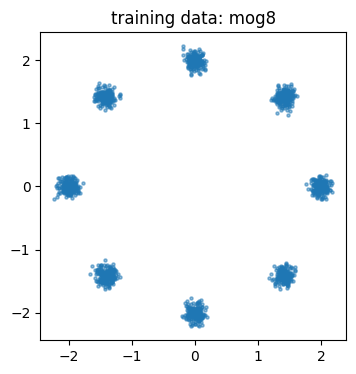

In [4]:
def make_mog8_centers(radius=2.0):
    angles = jnp.linspace(0.0, 2.0 * jnp.pi, 8, endpoint=False)
    return radius * jnp.stack([jnp.cos(angles), jnp.sin(angles)], axis=1)


def sample_mog8(key, n, radius=2.0, sigma=0.08):
    k_idx, k_eps = random.split(key)
    centers = make_mog8_centers(radius)
    idx = random.randint(k_idx, (n,), minval=0, maxval=centers.shape[0])
    x = centers[idx] + sigma * random.normal(k_eps, (n, 2))
    return x, {"kind": "mog8", "centers": centers, "sigma": sigma}


def sample_ring(key, n, radius=1.7, radial_sigma=0.045):
    k_theta, k_r = random.split(key)
    theta = random.uniform(k_theta, (n,), minval=0.0, maxval=2.0 * jnp.pi)
    r = radius + radial_sigma * random.normal(k_r, (n,))
    x = jnp.stack([r * jnp.cos(theta), r * jnp.sin(theta)], axis=1)
    return x, {"kind": "ring", "radius": radius, "n_bins": 36}


def moon_reference(n_per_moon=40):
    th = jnp.linspace(0.0, jnp.pi, n_per_moon)
    m1 = jnp.stack([jnp.cos(th), jnp.sin(th)], axis=1)
    m2 = jnp.stack([1.0 - jnp.cos(th), -jnp.sin(th) - 0.55], axis=1)
    ref = jnp.concatenate([m1, m2], axis=0)
    return 1.35 * (ref - jnp.mean(ref, axis=0, keepdims=True))


def sample_moons(key, n, noise=0.055):
    k_sel, k_theta, k_eps, k_perm = random.split(key, 4)
    is_second = random.bernoulli(k_sel, 0.5, (n,))
    th = random.uniform(k_theta, (n,), minval=0.0, maxval=jnp.pi)
    m1 = jnp.stack([jnp.cos(th), jnp.sin(th)], axis=1)
    m2 = jnp.stack([1.0 - jnp.cos(th), -jnp.sin(th) - 0.55], axis=1)
    x = jnp.where(is_second[:, None], m2, m1)
    x = 1.35 * (x - jnp.array([[0.5, 0.225]]))
    x = x + noise * random.normal(k_eps, (n, 2))
    x = x[random.permutation(k_perm, n)]
    return x, {"kind": "moons", "reference": moon_reference(50)}


def make_dataset(key, kind, n):
    if kind == "mog8":  return sample_mog8(key, n)
    if kind == "ring":  return sample_ring(key, n)
    if kind == "moons": return sample_moons(key, n)
    raise ValueError(kind)


key, sub = random.split(key)
train_data, data_meta = make_dataset(sub, DATASET, N_TRAIN)
key, sub = random.split(key)
heldout_data, _ = make_dataset(sub, DATASET, N_TRAIN)
print("Dataset:", data_meta["kind"], "| train_data shape:", train_data.shape)

plt.figure(figsize=(4.0, 4.0))
plt.scatter(np.asarray(train_data[:, 0]), np.asarray(train_data[:, 1]), s=5, alpha=0.5)
plt.gca().set_aspect("equal")
plt.title(f"training data: {DATASET}")
plt.show()

## OU corruption and the empirical-score oracle

Same forward OU process and oracle as v2. The oracle is the Bayes-optimal
force of the empirical training mixture and serves as a ceiling on what the
schedule can deliver.

In [5]:
def ou_coeffs(t, kBT=1.0):
    a = jnp.exp(-t)
    sigma2 = kBT * (1.0 - a * a)
    sigma2 = jnp.maximum(sigma2, 1e-6)
    return a, sigma2


def corrupt_ou(key, x0, t, kBT=1.0):
    eps = random.normal(key, x0.shape)
    a, sigma2 = ou_coeffs(t, kBT)
    a_b = a if jnp.asarray(a).ndim == 0 else a[:, None]
    s2_b = sigma2 if jnp.asarray(sigma2).ndim == 0 else sigma2[:, None]
    xt = a_b * x0 + jnp.sqrt(s2_b) * eps
    target_force = -kBT * (xt - a_b * x0) / s2_b
    return xt, target_force


@partial(jax.jit, static_argnums=(3,))
def empirical_force(x, t, data, max_data=None, kBT=1.0):
    if max_data is not None:
        data = data[:max_data]
    a, sigma2 = ou_coeffs(t, kBT)
    diff = x[:, None, :] - a * data[None, :, :]
    logits = -jnp.sum(diff * diff, axis=-1) / (2.0 * sigma2)
    w = jax.nn.softmax(logits, axis=1)
    posterior_mean = jnp.sum(w[:, :, None] * (a * data[None, :, :]), axis=1)
    return kBT * (posterior_mean - x) / sigma2


@partial(jax.jit, static_argnums=(3,))
def empirical_log_p(x, t, data, max_data=None, kBT=1.0):
    if max_data is not None:
        data = data[:max_data]
    a, sigma2 = ou_coeffs(t, kBT)
    diff = x[:, None, :] - a * data[None, :, :]
    logits = -jnp.sum(diff * diff, axis=-1) / (2.0 * sigma2)
    return logsumexp(logits, axis=1)

## Binary RBM model

Exactly Model 2 of the v2 notebook, but parameterised by the hidden width
$m$ and the visible-hidden coupling init scale $\sigma_W$. All other
primitives ($\log p$, equilibrium hidden activations, analytic force,
free energy) are unchanged.

In [6]:
def init_binary(key, data=None, m=DEFAULT_M, W_scale=DEFAULT_W_SCALE,
                b_scale=DEFAULT_B_SCALE):
    kW, kb = random.split(key)
    return {
        "W": W_scale * random.normal(kW, (2, m)),
        "b": b_scale * random.normal(kb, (m,)),
    }


def binary_log_p(params, x, sigma2):
    quad = -0.5 * jnp.sum(x ** 2) / sigma2
    logits = jnp.dot(x, params["W"]) + params["b"]
    hidden = jnp.sum(jax.nn.softplus(logits)) / sigma2
    return quad + hidden


def binary_hidden_eq(params, x_batch):
    logits = x_batch @ params["W"] + params["b"]
    return jax.nn.sigmoid(logits)


def binary_force_analytic(params, x_batch, sigma2):
    h = binary_hidden_eq(params, x_batch)
    return (-x_batch + h @ params["W"].T) / sigma2


_binary_grad_single = jax.grad(binary_log_p, argnums=1)


def binary_force(params, x_batch, sigma2):
    return jax.vmap(lambda x: _binary_grad_single(params, x, sigma2))(x_batch)


def binary_free_energy(params, x_batch, sigma2):
    return -jax.vmap(lambda x: binary_log_p(params, x, sigma2))(x_batch)


# Sanity: autograd vs. analytic force must agree.
key, sub = random.split(key)
x_test = random.normal(sub, (32, 2))
for sigma2_test in [0.05, 0.5, 2.0]:
    key, k_init = random.split(key)
    p = init_binary(k_init, train_data, m=DEFAULT_M)
    err = float(jnp.max(jnp.abs(
        binary_force(p, x_test, sigma2_test) - binary_force_analytic(p, x_test, sigma2_test))))
    print(f"sigma^2={sigma2_test:.2f}  | max |autograd - analytic| = {err:.2e}")

sigma^2=0.05  | max |autograd - analytic| = 1.34e-05
sigma^2=0.50  | max |autograd - analytic| = 9.54e-07
sigma^2=2.00  | max |autograd - analytic| = 2.38e-07


## Per-slice training (warm-started, high-noise to low-noise)

Same DSM protocol as v2: train at each diffusion time, warm-start from the
next-higher noise slice.

In [7]:
def make_per_slice_loss(force_fn, batch_size, reg_scale, kBT_val):
    def loss(params, key, data, t):
        k_idx, k_noise = random.split(key)
        idx = random.randint(k_idx, (batch_size,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, target = corrupt_ou(k_noise, x0, t, kBT_val)
        sigma2 = ou_coeffs(t, kBT_val)[1]
        pred = force_fn(params, xt, sigma2)
        mse = 0.5 * jnp.mean(jnp.sum((pred - target) ** 2, axis=-1))
        return mse + reg_scale * tree_sqnorm(params)
    return loss


def train_binary(key, data, t_grid, m, W_scale=DEFAULT_W_SCALE,
                 b_scale=DEFAULT_B_SCALE, lr=DEFAULT_LR,
                 steps_per_time=STEPS_PER_TIME_SWEEP,
                 batch_size=BATCH_SIZE, reg_scale=REG_SCALE,
                 grad_clip=GRAD_CLIP, verbose=False):
    key, k_init = random.split(key)
    params = init_binary(k_init, data, m=m, W_scale=W_scale, b_scale=b_scale)
    params_by_idx = [None for _ in range(len(t_grid))]
    losses_by_idx = [None for _ in range(len(t_grid))]
    loss_fn = make_per_slice_loss(binary_force_analytic, batch_size, reg_scale, kBT)
    loss_and_grad = jax.jit(jax.value_and_grad(loss_fn))
    t0_wall = time.time()
    for idx in range(len(t_grid) - 1, -1, -1):
        opt_state = adam_init(params)
        t = t_grid[idx]
        per_step_losses = []
        last_loss = None
        for _ in range(steps_per_time):
            key, sub = random.split(key)
            loss_val, grads = loss_and_grad(params, sub, data, t)
            grads = clip_tree(grads, grad_clip)
            params, opt_state = adam_step(params, opt_state, grads, lr=lr)
            per_step_losses.append(loss_val)
            last_loss = loss_val
        params_by_idx[idx] = params
        losses_by_idx[idx] = np.asarray(jax.device_get(per_step_losses))
        if verbose:
            s2 = float(ou_coeffs(t)[1])
            print(f"  t={float(t):.3f} | sigma_t^2={s2:.4f} | loss={float(last_loss):.4e}")
    wall = time.time() - t0_wall
    return params_by_idx, losses_by_idx, wall, key

## Reverse-time sampler (equilibrium-hidden)

We use the equilibrium-hidden sampler throughout this notebook; the
finite-hidden-time analysis is left to v2.

In [8]:
def nearest_time_idx(t, t_grid):
    return int(np.argmin(np.abs(np.asarray(t_grid) - float(t))))


def reverse_sample_binary(key, params_seq, t_grid, n_samples=N_SAMPLES,
                          n_steps=N_REVERSE_STEPS, clip_x=8.0):
    key, k_init = random.split(key)
    x = jnp.sqrt(kBT) * random.normal(k_init, (n_samples, 2))
    dt = TAU / n_steps
    for step in range(n_steps):
        s = max(T_MIN, TAU - step * dt)
        params = params_seq[nearest_time_idx(s, t_grid)]
        sigma2 = float(ou_coeffs(s)[1])
        f = binary_force_analytic(params, x, sigma2)
        key, k_noise = random.split(key)
        x = x + (x + 2.0 * f) * dt + jnp.sqrt(2.0 * kBT * dt) * random.normal(k_noise, x.shape)
        if clip_x is not None:
            x = jnp.clip(x, -clip_x, clip_x)
    return x, key

## Evaluation metrics

- **Coverage / KL / mean nearest-mode distance.** Same definitions as v2.
  Mean nearest-mode distance is the metric that actually moves on `mog8`,
  since trivial coverage saturates at $1.0$.
- **Score-error nRMSE.** Normalised RMSE of the model force against the
  empirical oracle, at several diffusion times.
- **Memorization diagnostic.** Median nearest-training-point distance of
  generated samples, compared against the same statistic for a fresh
  held-out batch drawn from the same data distribution. If the model is
  memorising, generated samples lie much closer to specific training
  points than independent draws would.

In [9]:
def coverage_metrics(samples_x, meta, min_frac=0.005):
    x = np.asarray(samples_x)
    n = x.shape[0]
    kind = meta["kind"]
    if kind == "mog8":
        centers = np.asarray(meta["centers"])
        d2 = ((x[:, None, :] - centers[None, :, :]) ** 2).sum(axis=-1)
        labels = d2.argmin(axis=1)
        counts = np.bincount(labels, minlength=centers.shape[0])
        threshold = max(2, int(min_frac * n))
        coverage = float(np.mean(counts >= threshold))
        probs = counts / max(1, counts.sum())
        uniform = np.ones_like(probs) / len(probs)
        kl = float(np.sum(np.where(probs > 0, probs * np.log(probs / uniform), 0.0)))
        mean_d = float(np.mean(np.sqrt(d2.min(axis=1))))
        return {"coverage": coverage, "kl_to_uniform": kl,
                "mean_nearest_dist": mean_d, "counts": counts}
    if kind == "ring":
        theta = np.mod(np.arctan2(x[:, 1], x[:, 0]), 2.0 * np.pi)
        bins = meta.get("n_bins", 36)
        labels = np.floor(theta / (2.0 * np.pi) * bins).astype(int)
        counts = np.bincount(labels, minlength=bins)
        threshold = max(2, int(min_frac * n))
        coverage = float(np.mean(counts >= threshold))
        r = np.sqrt((x ** 2).sum(axis=1))
        rmse = float(np.sqrt(np.mean((r - meta["radius"]) ** 2)))
        return {"coverage": coverage, "radial_rmse": rmse,
                "mean_nearest_dist": rmse, "counts": counts,
                "kl_to_uniform": float("nan")}
    if kind == "moons":
        ref = np.asarray(meta["reference"])
        d2 = ((x[:, None, :] - ref[None, :, :]) ** 2).sum(axis=-1)
        labels = d2.argmin(axis=1)
        counts = np.bincount(labels, minlength=ref.shape[0])
        threshold = max(1, int(min_frac * n))
        coverage = float(np.mean(counts >= threshold))
        mean_d = float(np.mean(np.sqrt(d2.min(axis=1))))
        return {"coverage": coverage, "mean_nearest_dist": mean_d,
                "counts": counts, "kl_to_uniform": float("nan")}
    raise ValueError(kind)


def score_error_binary(params_seq, t_grid, key, data,
                        t_values=(0.05, 0.15, 0.4, 1.0, 2.0), n=SCORE_TEST_N):
    out = []
    for t in t_values:
        if t < T_MIN or t > TAU:
            continue
        key, k_idx, k_noise = random.split(key, 3)
        idx = random.randint(k_idx, (n,), minval=0, maxval=data.shape[0])
        x0 = data[idx]
        xt, _ = corrupt_ou(k_noise, x0, t, kBT)
        f_exact = empirical_force(xt, t, data, min(2048, data.shape[0]), kBT)
        sigma2 = float(ou_coeffs(t)[1])
        params = params_seq[nearest_time_idx(t, t_grid)]
        f_pred = binary_force_analytic(params, xt, sigma2)
        mse = jnp.mean(jnp.sum((f_pred - f_exact) ** 2, axis=-1))
        denom = jnp.mean(jnp.sum(f_exact ** 2, axis=-1)) + 1e-8
        out.append({"t": float(t), "nrmse": float(jnp.sqrt(mse / denom)),
                    "mse": float(mse)})
    return out, key


def memorization_metric(samples_x, train_x, reference_x):
    """Median nearest-train-point distance for samples vs. reference draws.

    A model that memorises has gen_median << ref_median. A model that
    generalises has gen_median ~ ref_median.
    """
    s = np.asarray(samples_x)
    t = np.asarray(train_x)
    r = np.asarray(reference_x)
    d2_gen = ((s[:, None, :] - t[None, :, :]) ** 2).sum(axis=-1).min(axis=1)
    d2_ref = ((r[:, None, :] - t[None, :, :]) ** 2).sum(axis=-1).min(axis=1)
    return {
        "gen_median_nn_dist": float(np.median(np.sqrt(d2_gen))),
        "ref_median_nn_dist": float(np.median(np.sqrt(d2_ref))),
        "gen_to_ref_ratio": float(np.median(np.sqrt(d2_gen)) /
                                   max(1e-8, np.median(np.sqrt(d2_ref)))),
    }


def evaluate_config(key, params_seq, t_grid, label=""):
    key, sub = random.split(key)
    samples, key = reverse_sample_binary(sub, params_seq, t_grid,
                                         n_samples=N_SAMPLES)
    cov = coverage_metrics(samples, data_meta)
    key, sub = random.split(key)
    serr, key = score_error_binary(params_seq, t_grid, sub, train_data)
    mem = memorization_metric(samples, train_data, heldout_data)
    return {
        "label": label,
        "coverage": cov.get("coverage", float("nan")),
        "mean_nearest_dist": cov.get("mean_nearest_dist", float("nan")),
        "kl_to_uniform": cov.get("kl_to_uniform", float("nan")),
        "score_err": serr,
        "memorization": mem,
        "samples": samples,
    }, key

## Baseline run — default hyperparameters

Reproduces the v2 binary-RBM with $m=64$, $\sigma_W = 0.3$, $\eta = 5\!\times\!10^{-3}$,
$N_{\text{time}}=10$, $250$ steps per slice. All sweeps below are normalised against this.

In [10]:
print("Training baseline binary RBM (m=64) ...")
key, sub = random.split(key)
baseline_params, baseline_losses, baseline_wall, key = train_binary(
    sub, train_data, TIME_GRID_SWEEP,
    m=DEFAULT_M, W_scale=DEFAULT_W_SCALE,
    lr=DEFAULT_LR, steps_per_time=STEPS_PER_TIME_SWEEP,
    verbose=True)
print(f"baseline wall time: {baseline_wall:.1f}s")

key, sub = random.split(key)
baseline_eval, key = evaluate_config(sub, baseline_params, TIME_GRID_SWEEP,
                                      label="baseline m=64")
print("\nbaseline metrics:")
print(f"  coverage           = {baseline_eval['coverage']:.3f}")
print(f"  mean_nearest_dist  = {baseline_eval['mean_nearest_dist']:.4f}")
print(f"  kl_to_uniform      = {baseline_eval['kl_to_uniform']:.4f}")
print(f"  memorization ratio = {baseline_eval['memorization']['gen_to_ref_ratio']:.3f}")
for row in baseline_eval["score_err"]:
    print(f"  score_err t={row['t']:.3f}  nRMSE={row['nrmse']:.3f}")

Training baseline binary RBM (m=64) ...
  t=2.500 | sigma_t^2=0.9933 | loss=2.0356e-02
  t=2.224 | sigma_t^2=0.9883 | loss=2.4205e-02
  t=1.949 | sigma_t^2=0.9797 | loss=4.2501e-02
  t=1.673 | sigma_t^2=0.9648 | loss=7.0170e-02
  t=1.398 | sigma_t^2=0.9389 | loss=1.2015e-01
  t=1.122 | sigma_t^2=0.8940 | loss=2.1501e-01
  t=0.847 | sigma_t^2=0.8161 | loss=3.7538e-01
  t=0.571 | sigma_t^2=0.6809 | loss=6.9093e-01
  t=0.296 | sigma_t^2=0.4463 | loss=1.4575e+00
  t=0.020 | sigma_t^2=0.0392 | loss=2.1676e+01
baseline wall time: 13.4s

baseline metrics:
  coverage           = 1.000
  mean_nearest_dist  = 0.6552
  kl_to_uniform      = 0.0118
  memorization ratio = 41.591
  score_err t=0.050  nRMSE=0.878
  score_err t=0.150  nRMSE=0.797
  score_err t=0.400  nRMSE=0.419
  score_err t=1.000  nRMSE=0.075
  score_err t=2.000  nRMSE=0.007


## Sweep A — hidden width $m$

We sweep $m \in \{8, 16, 32, 64, 128, 256\}$ holding all other
hyperparameters fixed. Per §9.2 of the note this is the primary
expressivity dial: more softplus factors → richer marginal free energy →
in principle a tighter approximation of the noised data marginal $p_t$. We
expect to see the score-error nRMSE drop with $m$, but at some point
diminishing returns and a memorization signal (gen-to-ref nearest-neighbour
ratio dropping well below 1.0).

In [11]:
M_VALUES = [8, 16, 32, 64, 128, 256]

sweep_A_results = {}
for m_val in M_VALUES:
    print(f"\n--- Sweep A | m = {m_val} ---")
    key, sub = random.split(key)
    params_seq, losses_seq, wall, key = train_binary(
        sub, train_data, TIME_GRID_SWEEP,
        m=m_val, W_scale=DEFAULT_W_SCALE,
        lr=DEFAULT_LR, steps_per_time=STEPS_PER_TIME_SWEEP)
    key, sub = random.split(key)
    ev, key = evaluate_config(sub, params_seq, TIME_GRID_SWEEP,
                               label=f"m={m_val}")
    ev["params"] = params_seq
    ev["losses"] = losses_seq
    ev["wall"] = wall
    sweep_A_results[m_val] = ev
    print(f"  wall={wall:.1f}s | coverage={ev['coverage']:.3f} | "
          f"mean_nn_dist={ev['mean_nearest_dist']:.4f} | "
          f"mem_ratio={ev['memorization']['gen_to_ref_ratio']:.3f}")


--- Sweep A | m = 8 ---
  wall=9.9s | coverage=1.000 | mean_nn_dist=0.5071 | mem_ratio=28.958

--- Sweep A | m = 16 ---
  wall=7.3s | coverage=1.000 | mean_nn_dist=0.5506 | mem_ratio=33.465

--- Sweep A | m = 32 ---
  wall=7.3s | coverage=1.000 | mean_nn_dist=0.5717 | mem_ratio=35.537

--- Sweep A | m = 64 ---
  wall=6.0s | coverage=1.000 | mean_nn_dist=0.5841 | mem_ratio=36.335

--- Sweep A | m = 128 ---
  wall=7.5s | coverage=1.000 | mean_nn_dist=0.7199 | mem_ratio=46.921

--- Sweep A | m = 256 ---
  wall=7.3s | coverage=1.000 | mean_nn_dist=0.7119 | mem_ratio=47.231


### Sweep A — visual summary

Top row: scatter of generated samples for each $m$. Bottom row: metric
curves vs. $m$ (lower is better for mean nearest-mode distance and the
low-$t$ score nRMSE). The memorization ratio panel reads $1.0$ for a
model whose samples are statistically indistinguishable from fresh data
draws and trends to $0$ as the model collapses onto training points.

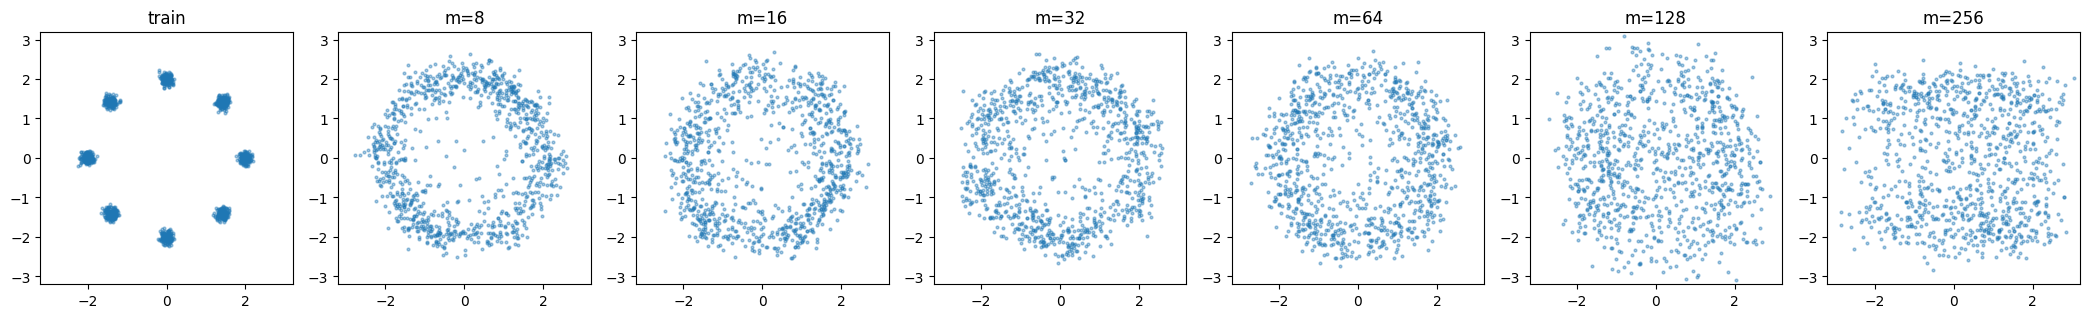

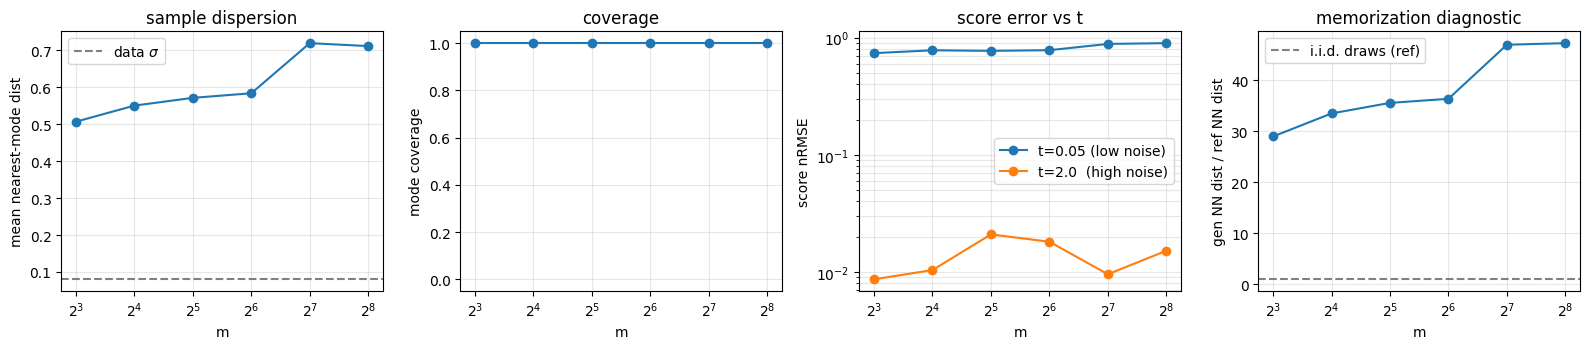

selected best m = 8


In [12]:
fig, axes = plt.subplots(1, len(M_VALUES) + 1, figsize=(3.0 * (len(M_VALUES) + 1), 3.0),
                          squeeze=False)
axes = axes[0]
axes[0].scatter(np.asarray(train_data[:, 0]), np.asarray(train_data[:, 1]),
                 s=4, alpha=0.4)
axes[0].set_title("train")
axes[0].set_aspect("equal")
axes[0].set_xlim(-GRID_LIM, GRID_LIM); axes[0].set_ylim(-GRID_LIM, GRID_LIM)
for ax, m_val in zip(axes[1:], M_VALUES):
    ev = sweep_A_results[m_val]
    s = np.asarray(ev["samples"])
    ax.scatter(s[:, 0], s[:, 1], s=4, alpha=0.4)
    ax.set_title(f"m={m_val}")
    ax.set_aspect("equal")
    ax.set_xlim(-GRID_LIM, GRID_LIM); ax.set_ylim(-GRID_LIM, GRID_LIM)
plt.tight_layout(); plt.show()

ms = np.array(M_VALUES)
mean_nn = np.array([sweep_A_results[m]["mean_nearest_dist"] for m in M_VALUES])
cov_arr = np.array([sweep_A_results[m]["coverage"] for m in M_VALUES])
mem_arr = np.array([sweep_A_results[m]["memorization"]["gen_to_ref_ratio"] for m in M_VALUES])
score_low = np.array([sweep_A_results[m]["score_err"][0]["nrmse"] for m in M_VALUES])
score_high = np.array([sweep_A_results[m]["score_err"][-1]["nrmse"] for m in M_VALUES])

fig, axes = plt.subplots(1, 4, figsize=(16.0, 3.6))
axes[0].plot(ms, mean_nn, marker="o")
axes[0].axhline(float(data_meta.get("sigma", 0.08)), color="grey", linestyle="--",
                 label=f"data $\\sigma$")
axes[0].set_xscale("log", base=2); axes[0].set_xlabel("m"); axes[0].set_ylabel("mean nearest-mode dist")
axes[0].set_title("sample dispersion"); axes[0].legend(); axes[0].grid(alpha=0.3, which="both")

axes[1].plot(ms, cov_arr, marker="o")
axes[1].set_xscale("log", base=2); axes[1].set_xlabel("m"); axes[1].set_ylabel("mode coverage")
axes[1].set_title("coverage"); axes[1].grid(alpha=0.3, which="both"); axes[1].set_ylim(-0.05, 1.05)

axes[2].plot(ms, score_low, marker="o", label="t=0.05 (low noise)")
axes[2].plot(ms, score_high, marker="o", label="t=2.0  (high noise)")
axes[2].set_xscale("log", base=2); axes[2].set_xlabel("m")
axes[2].set_ylabel("score nRMSE"); axes[2].set_yscale("log")
axes[2].set_title("score error vs t"); axes[2].legend(); axes[2].grid(alpha=0.3, which="both")

axes[3].plot(ms, mem_arr, marker="o")
axes[3].axhline(1.0, color="grey", linestyle="--", label="i.i.d. draws (ref)")
axes[3].set_xscale("log", base=2); axes[3].set_xlabel("m")
axes[3].set_ylabel("gen NN dist / ref NN dist")
axes[3].set_title("memorization diagnostic"); axes[3].legend(); axes[3].grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

# Pick the best m: smallest mean_nearest_dist where memorization ratio stays > 0.5.
# (Half the reference ratio is our crude floor; tweak if a sweep collapses.)
candidate_ms = [m for m, ev in sweep_A_results.items()
                if ev["memorization"]["gen_to_ref_ratio"] > 0.5]
if not candidate_ms:
    candidate_ms = list(sweep_A_results.keys())
best_m = min(candidate_ms,
              key=lambda m: sweep_A_results[m]["mean_nearest_dist"])
print(f"selected best m = {best_m}")

## Sweep B — visible-hidden coupling init scale $\sigma_W$

At fixed $m = $ `best_m`, the initial scale of $W$ controls the initial
spread of softplus knees. Too small and most hidden units are dead at
init (linear regime, nothing to learn from); too large and the softplus
saturates from the start (gradient kills). This sweep finds the operating
scale that pairs best with the chosen $m$ — orthogonal to the expressivity
axis swept above.


--- Sweep B | W_scale = 0.05 ---
  wall=6.2s | coverage=1.000 | mean_nn_dist=0.5358 | mem_ratio=33.034

--- Sweep B | W_scale = 0.1 ---
  wall=6.1s | coverage=1.000 | mean_nn_dist=0.5155 | mem_ratio=30.279

--- Sweep B | W_scale = 0.3 ---
  wall=6.1s | coverage=1.000 | mean_nn_dist=0.5248 | mem_ratio=30.958

--- Sweep B | W_scale = 1.0 ---
  wall=6.5s | coverage=1.000 | mean_nn_dist=0.4993 | mem_ratio=28.789

--- Sweep B | W_scale = 3.0 ---
  wall=6.5s | coverage=1.000 | mean_nn_dist=0.5291 | mem_ratio=31.434


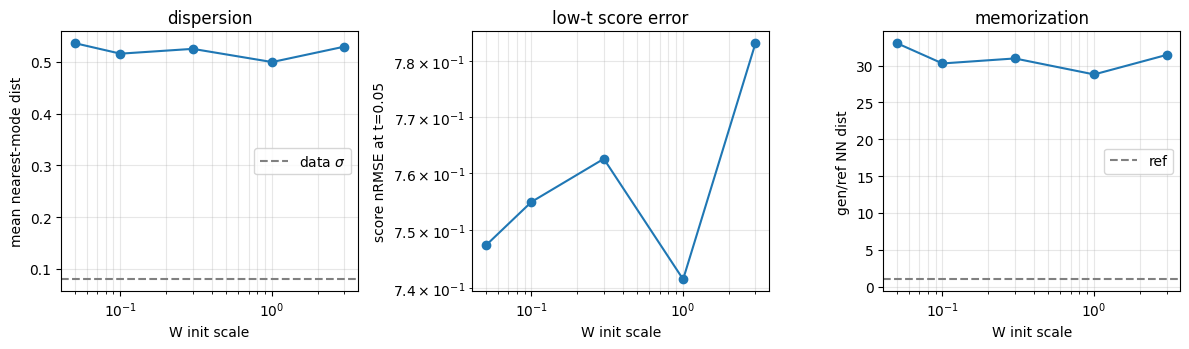

selected best W_scale = 1.0


In [13]:
W_SCALE_VALUES = [0.05, 0.1, 0.3, 1.0, 3.0]

sweep_B_results = {}
for w_val in W_SCALE_VALUES:
    print(f"\n--- Sweep B | W_scale = {w_val} ---")
    key, sub = random.split(key)
    params_seq, losses_seq, wall, key = train_binary(
        sub, train_data, TIME_GRID_SWEEP,
        m=best_m, W_scale=w_val,
        lr=DEFAULT_LR, steps_per_time=STEPS_PER_TIME_SWEEP)
    key, sub = random.split(key)
    ev, key = evaluate_config(sub, params_seq, TIME_GRID_SWEEP,
                               label=f"W_scale={w_val}")
    ev["params"] = params_seq
    ev["losses"] = losses_seq
    sweep_B_results[w_val] = ev
    print(f"  wall={wall:.1f}s | coverage={ev['coverage']:.3f} | "
          f"mean_nn_dist={ev['mean_nearest_dist']:.4f} | "
          f"mem_ratio={ev['memorization']['gen_to_ref_ratio']:.3f}")

ws = np.array(W_SCALE_VALUES)
mean_nn = np.array([sweep_B_results[w]["mean_nearest_dist"] for w in W_SCALE_VALUES])
score_low = np.array([sweep_B_results[w]["score_err"][0]["nrmse"] for w in W_SCALE_VALUES])
mem_arr = np.array([sweep_B_results[w]["memorization"]["gen_to_ref_ratio"] for w in W_SCALE_VALUES])

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.6))
axes[0].plot(ws, mean_nn, marker="o")
axes[0].axhline(float(data_meta.get("sigma", 0.08)), color="grey", linestyle="--",
                 label=f"data $\\sigma$")
axes[0].set_xscale("log"); axes[0].set_xlabel("W init scale")
axes[0].set_ylabel("mean nearest-mode dist"); axes[0].set_title("dispersion")
axes[0].legend(); axes[0].grid(alpha=0.3, which="both")

axes[1].plot(ws, score_low, marker="o")
axes[1].set_xscale("log"); axes[1].set_yscale("log"); axes[1].set_xlabel("W init scale")
axes[1].set_ylabel("score nRMSE at t=0.05"); axes[1].set_title("low-t score error")
axes[1].grid(alpha=0.3, which="both")

axes[2].plot(ws, mem_arr, marker="o")
axes[2].axhline(1.0, color="grey", linestyle="--", label="ref")
axes[2].set_xscale("log"); axes[2].set_xlabel("W init scale")
axes[2].set_ylabel("gen/ref NN dist"); axes[2].set_title("memorization")
axes[2].legend(); axes[2].grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

ok_ws = [w for w, ev in sweep_B_results.items()
         if ev["memorization"]["gen_to_ref_ratio"] > 0.5]
if not ok_ws:
    ok_ws = list(sweep_B_results.keys())
best_W_scale = min(ok_ws, key=lambda w: sweep_B_results[w]["mean_nearest_dist"])
print(f"selected best W_scale = {best_W_scale}")

## Sweep C — learning rate $\eta$

Holding $(m, \sigma_W)$ at their swept-best values, sweep the Adam
learning rate. Too small under-trains within `steps_per_time`; too large
destabilises the per-slice optimisation (especially at small $t$ where
the target force has magnitude $\sim 1/\sigma_t^2 \approx 25$).


--- Sweep C | lr = 0.001 ---
  wall=6.3s | coverage=1.000 | mean_nn_dist=0.5820 | mem_ratio=35.888

--- Sweep C | lr = 0.002 ---
  wall=6.4s | coverage=1.000 | mean_nn_dist=0.5103 | mem_ratio=29.606

--- Sweep C | lr = 0.005 ---
  wall=6.3s | coverage=1.000 | mean_nn_dist=0.5172 | mem_ratio=29.773

--- Sweep C | lr = 0.01 ---
  wall=6.2s | coverage=1.000 | mean_nn_dist=0.5044 | mem_ratio=29.573

--- Sweep C | lr = 0.02 ---
  wall=6.1s | coverage=1.000 | mean_nn_dist=0.4762 | mem_ratio=27.052


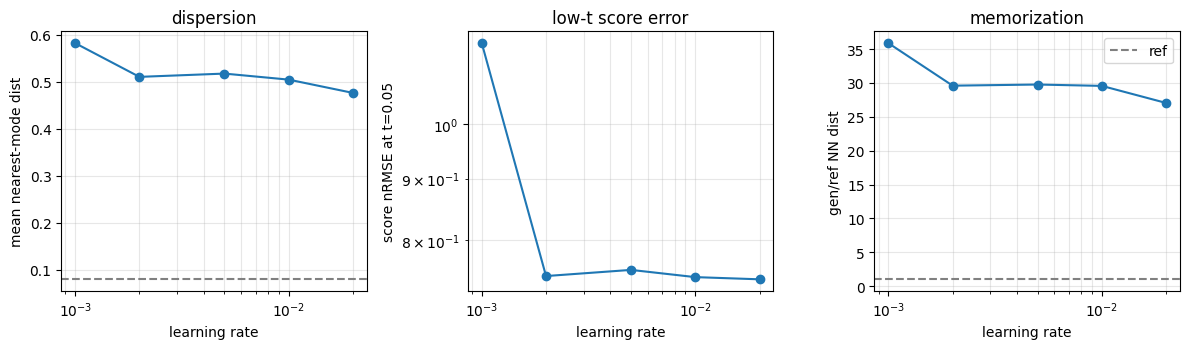

selected best lr = 0.02


In [14]:
LR_VALUES = [1e-3, 2e-3, 5e-3, 1e-2, 2e-2]

sweep_C_results = {}
for lr_val in LR_VALUES:
    print(f"\n--- Sweep C | lr = {lr_val:g} ---")
    key, sub = random.split(key)
    params_seq, losses_seq, wall, key = train_binary(
        sub, train_data, TIME_GRID_SWEEP,
        m=best_m, W_scale=best_W_scale,
        lr=lr_val, steps_per_time=STEPS_PER_TIME_SWEEP)
    key, sub = random.split(key)
    ev, key = evaluate_config(sub, params_seq, TIME_GRID_SWEEP,
                               label=f"lr={lr_val:g}")
    ev["params"] = params_seq
    ev["losses"] = losses_seq
    sweep_C_results[lr_val] = ev
    print(f"  wall={wall:.1f}s | coverage={ev['coverage']:.3f} | "
          f"mean_nn_dist={ev['mean_nearest_dist']:.4f} | "
          f"mem_ratio={ev['memorization']['gen_to_ref_ratio']:.3f}")

lrs = np.array(LR_VALUES)
mean_nn = np.array([sweep_C_results[lr]["mean_nearest_dist"] for lr in LR_VALUES])
score_low = np.array([sweep_C_results[lr]["score_err"][0]["nrmse"] for lr in LR_VALUES])
mem_arr = np.array([sweep_C_results[lr]["memorization"]["gen_to_ref_ratio"] for lr in LR_VALUES])

fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.6))
axes[0].plot(lrs, mean_nn, marker="o"); axes[0].set_xscale("log")
axes[0].set_xlabel("learning rate"); axes[0].set_ylabel("mean nearest-mode dist")
axes[0].axhline(float(data_meta.get("sigma", 0.08)), color="grey", linestyle="--")
axes[0].set_title("dispersion"); axes[0].grid(alpha=0.3, which="both")

axes[1].plot(lrs, score_low, marker="o"); axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("learning rate"); axes[1].set_ylabel("score nRMSE at t=0.05")
axes[1].set_title("low-t score error"); axes[1].grid(alpha=0.3, which="both")

axes[2].plot(lrs, mem_arr, marker="o"); axes[2].set_xscale("log")
axes[2].axhline(1.0, color="grey", linestyle="--", label="ref")
axes[2].set_xlabel("learning rate"); axes[2].set_ylabel("gen/ref NN dist")
axes[2].set_title("memorization"); axes[2].legend(); axes[2].grid(alpha=0.3, which="both")

plt.tight_layout(); plt.show()

ok_lrs = [lr for lr, ev in sweep_C_results.items()
          if ev["memorization"]["gen_to_ref_ratio"] > 0.5]
if not ok_lrs:
    ok_lrs = list(sweep_C_results.keys())
best_lr = min(ok_lrs, key=lambda lr: sweep_C_results[lr]["mean_nearest_dist"])
print(f"selected best lr = {best_lr:g}")

## Final tuned configuration

Best $(m, \sigma_W, \eta)$ retrained at the higher-resolution schedule
(`N_TIME_FINAL` slices, `STEPS_PER_TIME_FINAL` steps each). Direct side-by-side
with the baseline below.

In [15]:
print(f"final config: m={best_m}, W_scale={best_W_scale}, lr={best_lr:g}")
print(f"final schedule: N_TIME={N_TIME_FINAL}, steps_per_time={STEPS_PER_TIME_FINAL}")

key, sub = random.split(key)
final_params, final_losses, final_wall, key = train_binary(
    sub, train_data, TIME_GRID_FINAL,
    m=best_m, W_scale=best_W_scale,
    lr=best_lr, steps_per_time=STEPS_PER_TIME_FINAL,
    verbose=True)
print(f"final wall time: {final_wall:.1f}s")

key, sub = random.split(key)
final_eval, key = evaluate_config(sub, final_params, TIME_GRID_FINAL,
                                   label="final tuned")

print("\nfinal metrics:")
print(f"  coverage           = {final_eval['coverage']:.3f}")
print(f"  mean_nearest_dist  = {final_eval['mean_nearest_dist']:.4f}")
print(f"  kl_to_uniform      = {final_eval['kl_to_uniform']:.4f}")
print(f"  memorization ratio = {final_eval['memorization']['gen_to_ref_ratio']:.3f}")
for row in final_eval["score_err"]:
    print(f"  score_err t={row['t']:.3f}  nRMSE={row['nrmse']:.3f}")

final config: m=8, W_scale=1.0, lr=0.02
final schedule: N_TIME=16, steps_per_time=500
  t=2.500 | sigma_t^2=0.9933 | loss=1.6019e-02
  t=2.335 | sigma_t^2=0.9906 | loss=1.9165e-02
  t=2.169 | sigma_t^2=0.9869 | loss=2.5957e-02
  t=2.004 | sigma_t^2=0.9818 | loss=3.7166e-02
  t=1.839 | sigma_t^2=0.9747 | loss=5.0603e-02
  t=1.673 | sigma_t^2=0.9648 | loss=6.9352e-02
  t=1.508 | sigma_t^2=0.9510 | loss=9.9008e-02
  t=1.343 | sigma_t^2=0.9318 | loss=1.3366e-01
  t=1.177 | sigma_t^2=0.9051 | loss=1.8579e-01
  t=1.012 | sigma_t^2=0.8679 | loss=2.6840e-01
  t=0.847 | sigma_t^2=0.8161 | loss=3.5712e-01
  t=0.681 | sigma_t^2=0.7440 | loss=5.5632e-01
  t=0.516 | sigma_t^2=0.6437 | loss=7.6074e-01
  t=0.351 | sigma_t^2=0.5041 | loss=1.1952e+00
  t=0.185 | sigma_t^2=0.3097 | loss=1.9990e+00
  t=0.020 | sigma_t^2=0.0392 | loss=1.5570e+01
final wall time: 23.9s

final metrics:
  coverage           = 1.000
  mean_nearest_dist  = 0.4754
  kl_to_uniform      = 0.0245
  memorization ratio = 26.586
  sc

### Side-by-side: baseline vs. tuned

Samples, score-error curves, and energy landscape at the smallest
diffusion time.

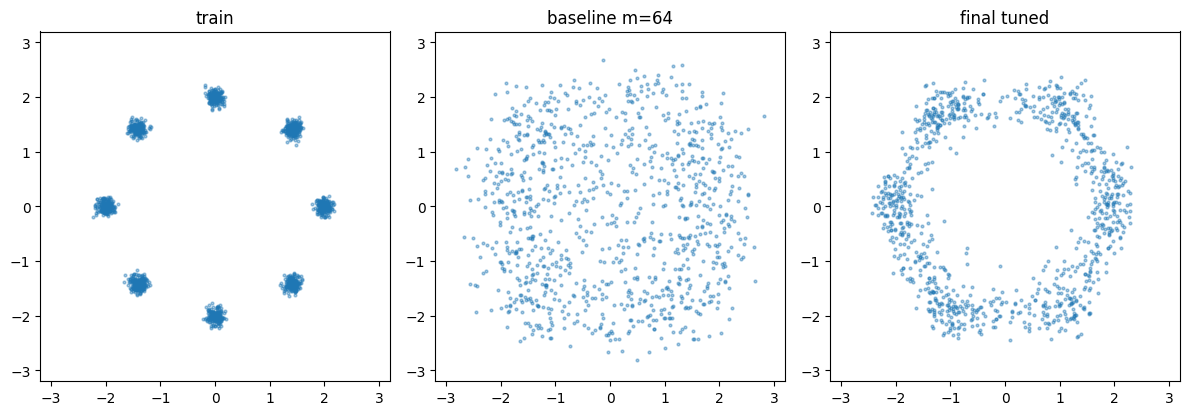

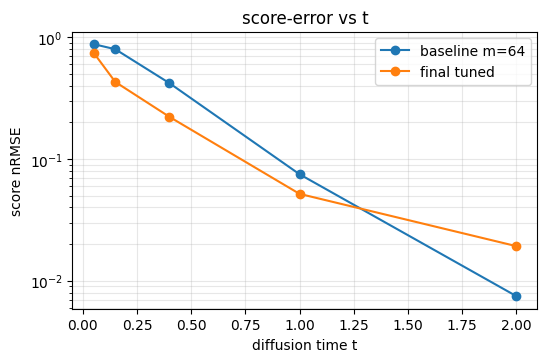

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.0))
axes[0].scatter(np.asarray(train_data[:, 0]), np.asarray(train_data[:, 1]),
                 s=4, alpha=0.4)
axes[0].set_title("train"); axes[0].set_aspect("equal")
axes[0].set_xlim(-GRID_LIM, GRID_LIM); axes[0].set_ylim(-GRID_LIM, GRID_LIM)
for ax, ev in zip(axes[1:], [baseline_eval, final_eval]):
    s = np.asarray(ev["samples"])
    ax.scatter(s[:, 0], s[:, 1], s=4, alpha=0.4)
    ax.set_title(ev["label"]); ax.set_aspect("equal")
    ax.set_xlim(-GRID_LIM, GRID_LIM); ax.set_ylim(-GRID_LIM, GRID_LIM)
plt.tight_layout(); plt.show()

ts_b = [row["t"] for row in baseline_eval["score_err"]]
nr_b = [row["nrmse"] for row in baseline_eval["score_err"]]
ts_f = [row["t"] for row in final_eval["score_err"]]
nr_f = [row["nrmse"] for row in final_eval["score_err"]]
plt.figure(figsize=(6.0, 3.6))
plt.plot(ts_b, nr_b, marker="o", label=baseline_eval["label"])
plt.plot(ts_f, nr_f, marker="o", label=final_eval["label"])
plt.yscale("log"); plt.xlabel("diffusion time t")
plt.ylabel("score nRMSE"); plt.title("score-error vs t")
plt.legend(); plt.grid(alpha=0.3, which="both")
plt.show()

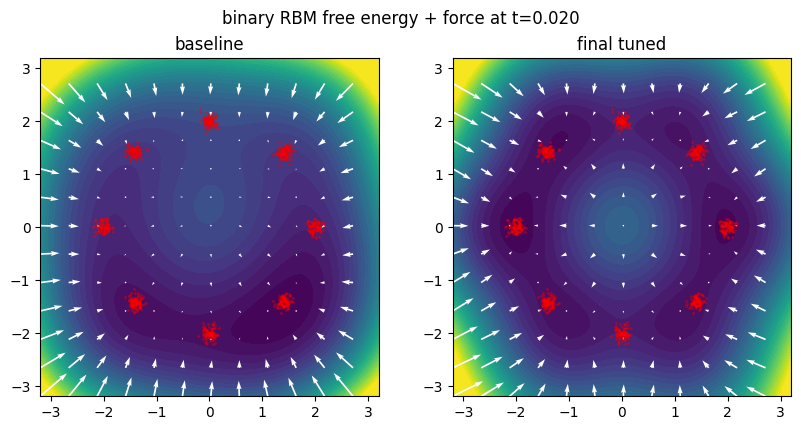

In [17]:
# Energy landscape and force field at the smallest diffusion time.
def make_grid(grid_lim=GRID_LIM, grid_n=GRID_N):
    xs = jnp.linspace(-grid_lim, grid_lim, grid_n)
    ys = jnp.linspace(-grid_lim, grid_lim, grid_n)
    X, Y = jnp.meshgrid(xs, ys)
    pts = jnp.stack([X.ravel(), Y.ravel()], axis=-1)
    return X, Y, pts


def plot_landscape(t_plot, ax, params_seq, t_grid, title):
    X, Y, pts = make_grid()
    sigma2 = float(ou_coeffs(t_plot)[1])
    p = params_seq[nearest_time_idx(t_plot, t_grid)]
    E = binary_free_energy(p, pts, sigma2)
    F = binary_force_analytic(p, pts, sigma2)
    Z = np.asarray(E).reshape(X.shape)
    lo, hi = np.percentile(Z, [2, 98])
    ax.contourf(np.asarray(X), np.asarray(Y), np.clip(Z, lo, hi), levels=40)
    F = np.asarray(F).reshape(X.shape + (2,))
    sl = slice(None, None, 10)
    scale = max(20.0, float(jnp.percentile(jnp.linalg.norm(jnp.asarray(F), axis=-1), 90)) * 2.5)
    ax.quiver(np.asarray(X)[sl, sl], np.asarray(Y)[sl, sl],
              F[sl, sl, 0], F[sl, sl, 1],
              angles="xy", scale_units="xy", scale=scale, color="white")
    ax.scatter(np.asarray(train_data[:800, 0]), np.asarray(train_data[:800, 1]),
                s=2, alpha=0.25, color="red")
    ax.set_title(title); ax.set_aspect("equal")
    ax.set_xlim(-GRID_LIM, GRID_LIM); ax.set_ylim(-GRID_LIM, GRID_LIM)


fig, axes = plt.subplots(1, 2, figsize=(8.4, 4.2))
plot_landscape(T_MIN, axes[0], baseline_params, TIME_GRID_SWEEP, "baseline")
plot_landscape(T_MIN, axes[1], final_params, TIME_GRID_FINAL, "final tuned")
plt.suptitle(f"binary RBM free energy + force at t={T_MIN:.3f}")
plt.tight_layout(); plt.show()

## Summary

1. **Sweep A (hidden width $m$).** Tests the primary expressivity dial
   from §9.2 of the note. The expected pattern is: monotonic improvement
   in mean nearest-mode distance and low-$t$ score nRMSE as $m$ grows,
   plateauing once the data manifold is covered; eventual drop of the
   memorization ratio below 1.0 once $m$ is large relative to dataset
   size.
2. **Sweep B (coupling init scale $\sigma_W$).** Orthogonal to capacity:
   places the softplus knees in a useful regime at init. Best to read
   alongside Sweep A — the optimum often shifts with $m$.
3. **Sweep C (learning rate $\eta$).** Finds the largest stable step size
   that still converges at small $t$, where the target force is largest.

The final tuned configuration is retrained at higher schedule resolution
and compared against the v2-style default. Read off:

- **Sample plot.** Whether the modes are recovered cleanly.
- **Score-nRMSE curve.** Whether the gain comes from low-$t$ (mode
  sharpening) or high-$t$ (large-scale coverage).
- **Free-energy landscape.** Whether the model has carved sharper basins
  around the modes.

**Next step** along the proposal's research path (§13.3) is to repeat the
$m$ sweep on $12\!\times\!12$ MNIST 0/1 — that environment is set up in
`latent_dam_mnist_jax.ipynb`.